In [1]:
# STEP 1 - Mount Google Drive

from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [2]:
# STEP 2 - Check Google Drive project folder

import os

drive_path = "/content/drive/MyDrive"

print("My Drive exists:", os.path.exists(drive_path))

print("\nFolders and files in My Drive:")
for item in os.listdir(drive_path):
    print("-", item)

My Drive exists: True

Folders and files in My Drive:
- Colab Notebooks
- 📚 Book
- UOM-fullstak 1
- DL Assignment


In [3]:
# STEP 3 - Check files inside DL Assignment

import os

project_path = "/content/drive/MyDrive/DL Assignment"

print("DL Assignment exists:", os.path.exists(project_path))

print("\nFiles inside DL Assignment:")
for item in os.listdir(project_path):
    print("-", item)

DL Assignment exists: True

Files inside DL Assignment:
- 01_DDR_Dataset_EDA.ipynb
- ddr_common_split.csv
- DDR.zip


In [4]:
# STEP 4 - Extract DDR dataset

import os
import zipfile

project_path = "/content/drive/MyDrive/DL Assignment"
dataset_zip = os.path.join(project_path, "DDR.zip")
extract_path = "/content"

print("DDR.zip exists:", os.path.exists(dataset_zip))

if os.path.exists(dataset_zip):

    if not os.path.exists("/content/DR_grading"):

        print("Extracting DDR dataset...")

        with zipfile.ZipFile(dataset_zip, "r") as zip_ref:
            zip_ref.extractall(extract_path)

        print("Extraction completed.")

    else:
        print("DDR dataset is already extracted.")

else:
    print("ERROR: DDR.zip was not found.")

print("DR_grading exists:", os.path.exists("/content/DR_grading"))

DDR.zip exists: True
Extracting DDR dataset...
Extraction completed.
DR_grading exists: True


In [5]:
# STEP 5 - Verify DDR image folder

import os

dataset_dir = "/content/DR_grading/DR_grading"

print("Dataset folder exists:", os.path.exists(dataset_dir))

if os.path.exists(dataset_dir):

    image_files = [
        f for f in os.listdir(dataset_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print("Image folder:", dataset_dir)
    print("Images found:", len(image_files))

    print("\nFirst 10 images:")
    for f in image_files[:10]:
        print(f)

Dataset folder exists: True
Image folder: /content/DR_grading/DR_grading
Images found: 12524

First 10 images:
007-0410-000.jpg
007-5909-300.jpg
007-1842-100.jpg
007-4440-200.jpg
20170424095919157.jpg
007-1148-000.jpg
20170427184002642.jpg
20170612163236281.jpg
007-5389-300.jpg
007-0594-000.jpg


In [6]:
# STEP 6 - Load common train/validation/test split

import pandas as pd
import os

split_csv = "/content/drive/MyDrive/DL Assignment/ddr_common_split.csv"

print("Split CSV exists:", os.path.exists(split_csv))

split_df = pd.read_csv(split_csv)

print("Total records:", len(split_df))
print("\nColumns:")
print(split_df.columns.tolist())

print("\nFirst 5 rows:")
display(split_df.head())

Split CSV exists: True
Total records: 12522

Columns:
['id_code', 'diagnosis', 'filepath', 'exists', 'split']

First 5 rows:


,id_code,diagnosis,filepath,exists,split
0,20170209143259326.jpg,0,/content/DDR/DR_grading/DR_grading/20170209143...,True,train
1,007-3253-100.jpg,1,/content/DDR/DR_grading/DR_grading/007-3253-10...,True,train
2,007-6141-300.jpg,2,/content/DDR/DR_grading/DR_grading/007-6141-30...,True,train
3,007-3697-200.jpg,2,/content/DDR/DR_grading/DR_grading/007-3697-20...,True,train
4,007-7323-601.jpg,0,/content/DDR/DR_grading/DR_grading/007-7323-60...,True,train


In [7]:
# STEP 7 - Create train, validation and test dataframes

train_df = split_df[
    split_df["split"] == "train"
].copy()

val_df = split_df[
    split_df["split"] == "validation"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nClass distribution - Train:")
print(train_df["diagnosis"].value_counts().sort_index())

print("\nClass distribution - Validation:")
print(val_df["diagnosis"].value_counts().sort_index())

print("\nClass distribution - Test:")
print(test_df["diagnosis"].value_counts().sort_index())

Train images: 8765
Validation images: 1878
Test images: 1879

Class distribution - Train:
diagnosis
0    4386
1     441
2    3134
3     165
4     639
Name: count, dtype: int64

Class distribution - Validation:
diagnosis
0    940
1     94
2    671
3     36
4    137
Name: count, dtype: int64

Class distribution - Test:
diagnosis
0    940
1     95
2    672
3     35
4    137
Name: count, dtype: int64


In [8]:
# STEP 8 - Verify all image paths

print("Train missing files:",
      (~train_df["filepath"].apply(os.path.exists)).sum())

print("Validation missing files:",
      (~val_df["filepath"].apply(os.path.exists)).sum())

print("Test missing files:",
      (~test_df["filepath"].apply(os.path.exists)).sum())

print("\nTotal missing files:",
      (~split_df["filepath"].apply(os.path.exists)).sum())

Train missing files: 8765
Validation missing files: 1878
Test missing files: 1879

Total missing files: 12522


In [9]:
# STEP 8B - Correct image paths for this Colab environment

dataset_dir = "/content/DR_grading/DR_grading"

split_df["filepath"] = split_df["id_code"].apply(
    lambda x: os.path.join(dataset_dir, x)
)

# Re-create the three dataframes with corrected paths
train_df = split_df[
    split_df["split"] == "train"
].copy()

val_df = split_df[
    split_df["split"] == "validation"
].copy()

test_df = split_df[
    split_df["split"] == "test"
].copy()

print("Corrected image paths.")

print("\nTrain missing files:",
      (~train_df["filepath"].apply(os.path.exists)).sum())

print("Validation missing files:",
      (~val_df["filepath"].apply(os.path.exists)).sum())

print("Test missing files:",
      (~test_df["filepath"].apply(os.path.exists)).sum())

print("\nTotal missing files:",
      (~split_df["filepath"].apply(os.path.exists)).sum())

Corrected image paths.

Train missing files: 0
Validation missing files: 0
Test missing files: 0

Total missing files: 0


In [10]:
# STEP 9 - Define Diabetic Retinopathy class names

class_names = [
    "No DR",
    "Mild DR",
    "Moderate DR",
    "Severe DR",
    "Proliferative DR"
]

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)

print("\nClass mapping:")
for i, name in enumerate(class_names):
    print(f"{i} -> {name}")

Number of classes: 5

Class mapping:
0 -> No DR
1 -> Mild DR
2 -> Moderate DR
3 -> Severe DR
4 -> Proliferative DR


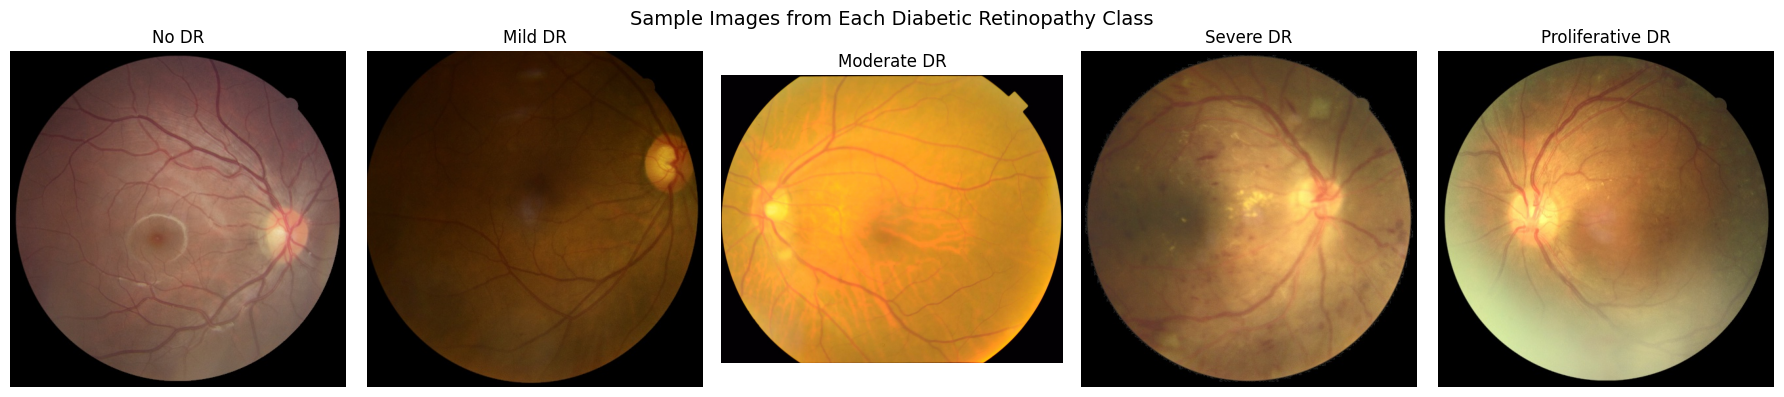

In [11]:
# STEP 10 - Display one sample image from each class

import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(18, 4))

for class_id in range(NUM_CLASSES):

    sample = train_df[
        train_df["diagnosis"] == class_id
    ].iloc[0]

    image = Image.open(sample["filepath"])

    plt.subplot(1, NUM_CLASSES, class_id + 1)
    plt.imshow(image)
    plt.title(class_names[class_id])
    plt.axis("off")

plt.suptitle(
    "Sample Images from Each Diabetic Retinopathy Class",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [12]:
# STEP 11 - TensorFlow and training configuration

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5
SEED = 42

print("\nTraining Configuration")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Random seed:", SEED)

# GPU verification
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("\nGPU detected successfully!")
    for gpu in gpus:
        print(gpu)
else:
    print("\nWARNING: No GPU detected.")

TensorFlow version: 2.20.0

Training Configuration
Image size: (224, 224)
Batch size: 32
Number of classes: 5
Random seed: 42

GPU detected successfully!
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [13]:
# STEP 12 - Data Generators and Image Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Convert diagnosis labels to string for categorical classification
train_df["label"] = train_df["diagnosis"].astype(str)
val_df["label"] = val_df["diagnosis"].astype(str)
test_df["label"] = test_df["diagnosis"].astype(str)

# Training data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True
)

# Validation and test data: no augmentation
val_test_datagen = ImageDataGenerator()

# Training generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

# Validation generator
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Test generator
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nGenerators created successfully.")
print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 8765 validated image filenames belonging to 5 classes.
Found 1878 validated image filenames belonging to 5 classes.
Found 1879 validated image filenames belonging to 5 classes.

Generators created successfully.
Training samples: 8765
Validation samples: 1878
Test samples: 1879


In [14]:
# STEP 13 - EfficientNetB0 Model Architecture

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Load pretrained EfficientNetB0
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build classification model
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.30),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.20),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

# Display model architecture
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
# STEP 14 - Calculate Class Weights

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get the class labels from the training set only
classes = np.array(sorted(train_df["diagnosis"].unique()))

# Calculate balanced class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["diagnosis"]
)

# Create dictionary for Keras
class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print("Class weights:")
for cls, weight in class_weights.items():
    print(f"{cls} - {class_names[cls]}: {weight:.4f}")

Class weights:
0 - No DR: 0.3997
1 - Mild DR: 3.9751
2 - Moderate DR: 0.5593
3 - Severe DR: 10.6242
4 - Proliferative DR: 2.7433


In [16]:
# STEP 15 - Compile EfficientNetB0 Model

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")
print("Optimizer: Adam")
print("Learning rate: 1e-5")
print("Loss: Categorical Crossentropy")
print("Metric: Accuracy")

Model compiled successfully.
Optimizer: Adam
Learning rate: 1e-5
Loss: Categorical Crossentropy
Metric: Accuracy


In [17]:
# STEP 16 - Training Callbacks

checkpoint_path = (
    "/content/drive/MyDrive/DL Assignment/"
    "IT23177246_EfficientNetB0_best.keras"
)

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured successfully.")
print("Best model will be saved to:")
print(checkpoint_path)

Callbacks configured successfully.
Best model will be saved to:
/content/drive/MyDrive/DL Assignment/IT23177246_EfficientNetB0_best.keras


In [18]:
# STEP 17 - Train EfficientNetB0

EPOCHS = 15

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.2640 - loss: 1.7344
Epoch 1: val_loss improved from None to 1.47948, saving model to /content/drive/MyDrive/DL Assignment/IT23177246_EfficientNetB0_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DL Assignment/IT23177246_EfficientNetB0_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 271s 874ms/step - accuracy: 0.2783 - loss: 1.6770 - val_accuracy: 0.4196 - val_loss: 1.4795 - learning_rate: 1.0000e-05
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.2941 - loss: 1.6108
Epoch 2: val_loss did not improve from 1.47948
274/274 ━━━━━━━━━━━━━━━━━━━━ 186s 679ms/step - accuracy: 0.2874 - loss: 1.5861 - val_accuracy: 0.3940 - val_loss: 1.4849 - learning_rate: 1.0000e-05
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.2982 - loss: 1.5720
Epoch 3: val_loss improved from 1.47948 to 1.45470, saving model to /content/drive/MyDrive/DL Assignment/IT23177246_EfficientNetB0_best.keras



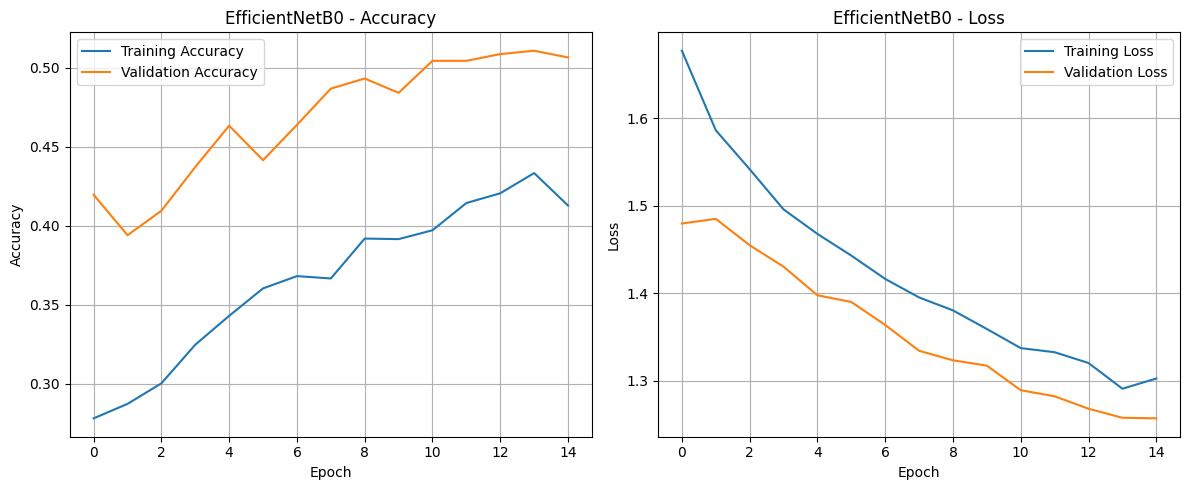

In [19]:
# STEP 18 - Plot Training History

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
# STEP 19 - Load Best EfficientNetB0 Model

from tensorflow.keras.models import load_model

best_model = load_model(
    "/content/drive/MyDrive/DL Assignment/IT23177246_EfficientNetB0_best.keras"
)

print("Best EfficientNetB0 model loaded successfully.")

Best EfficientNetB0 model loaded successfully.


In [21]:
# STEP 20 - Evaluate EfficientNetB0 on the Unseen Test Set

test_loss, test_accuracy = best_model.evaluate(
    test_generator,
    verbose=1
)

print("\nFinal Test Results")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Accuracy (%):", round(test_accuracy * 100, 2))

59/59 ━━━━━━━━━━━━━━━━━━━━ 38s 515ms/step - accuracy: 0.5130 - loss: 1.2581

Final Test Results
Test Loss: 1.2581
Test Accuracy: 0.513
Test Accuracy (%): 51.3


In [22]:
# STEP 21 - Generate Predictions on the Test Set

import numpy as np

# Reset test generator to the beginning
test_generator.reset()

# Generate predictions
y_prob = best_model.predict(test_generator, verbose=1)

# Predicted class labels
y_pred = np.argmax(y_prob, axis=1)

# True class labels
y_true = test_generator.classes

print("Prediction completed.")
print("Number of test samples:", len(y_true))
print("Number of predictions:", len(y_pred))

59/59 ━━━━━━━━━━━━━━━━━━━━ 32s 417ms/step
Prediction completed.
Number of test samples: 1879
Number of predictions: 1879


EfficientNetB0 - Test Set Metrics
----------------------------------
Accuracy : 0.5130
Precision: 0.6339
Recall   : 0.5130
F1-Score : 0.5264

Classification Report
                  precision    recall  f1-score   support

           No DR       0.77      0.74      0.76       940
         Mild DR       0.13      0.37      0.19        95
     Moderate DR       0.59      0.19      0.29       672
       Severe DR       0.10      0.80      0.17        35
Proliferative DR       0.40      0.56      0.47       137

        accuracy                           0.51      1879
       macro avg       0.40      0.53      0.37      1879
    weighted avg       0.63      0.51      0.53      1879



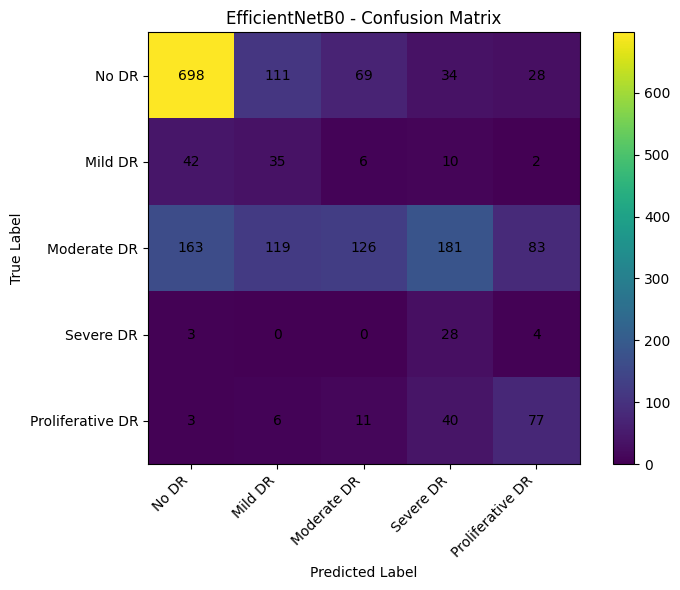

In [23]:
# STEP 22 - Classification Metrics and Confusion Matrix

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt

class_names = [
    "No DR",
    "Mild DR",
    "Moderate DR",
    "Severe DR",
    "Proliferative DR"
]

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true, y_pred, average="weighted", zero_division=0
)
recall = recall_score(
    y_true, y_pred, average="weighted", zero_division=0
)
f1 = f1_score(
    y_true, y_pred, average="weighted", zero_division=0
)

print("EfficientNetB0 - Test Set Metrics")
print("----------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("EfficientNetB0 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [24]:
# STEP 23 - ROC-AUC Evaluation

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Convert true labels to one-hot format
y_true_binary = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

# Calculate multiclass ROC-AUC using One-vs-Rest
roc_auc_macro = roc_auc_score(
    y_true_binary,
    y_prob,
    multi_class="ovr",
    average="macro"
)

roc_auc_weighted = roc_auc_score(
    y_true_binary,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print("EfficientNetB0 - ROC-AUC Results")
print("---------------------------------")
print(f"Macro ROC-AUC    : {roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC : {roc_auc_weighted:.4f}")

EfficientNetB0 - ROC-AUC Results
---------------------------------
Macro ROC-AUC    : 0.8121
Weighted ROC-AUC : 0.7816


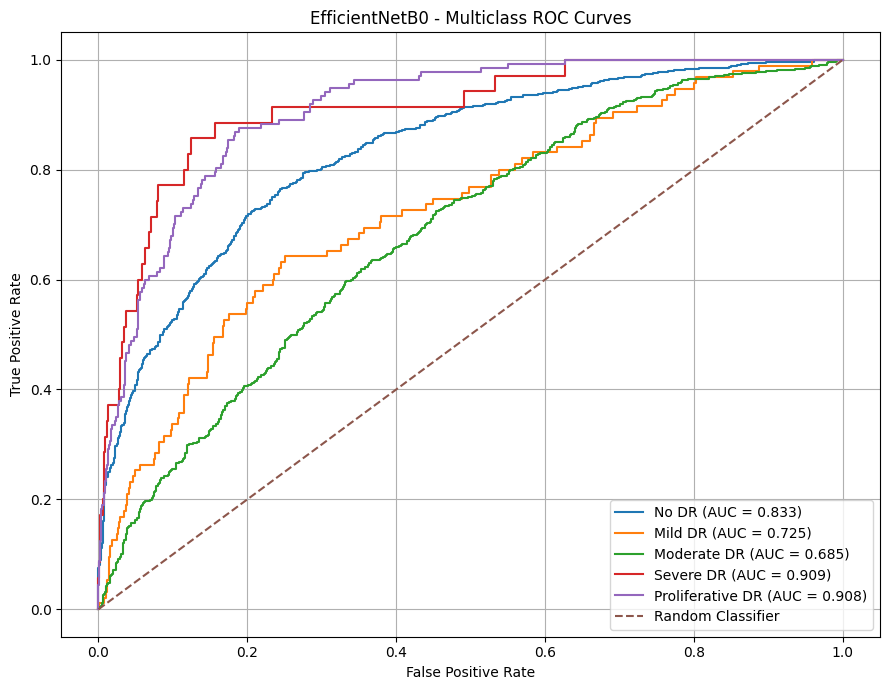

In [25]:
# STEP 24 - Multiclass ROC Curves

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize true labels
y_true_binary = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(9, 7))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(
        y_true_binary[:, i],
        y_prob[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {class_auc:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EfficientNetB0 - Multiclass ROC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# STEP 25 - Final EfficientNetB0 Results Summary

import pandas as pd

results_summary = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-Score",
        "Macro ROC-AUC",
        "Weighted ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc_macro,
        roc_auc_weighted
    ]
})

results_summary["Score"] = results_summary["Score"].round(4)

print("EfficientNetB0 - Final Test Set Results")
display(results_summary)

EfficientNetB0 - Final Test Set Results


,Metric,Score
0,Test Accuracy,0.5130
1,Weighted Precision,0.6339
2,Weighted Recall,0.5130
3,Weighted F1-Score,0.5264
4,Macro ROC-AUC,0.8121
5,Weighted ROC-AUC,0.7816


## EfficientNetB0 Architecture and Training Configuration

EfficientNetB0 was selected as the transfer-learning model for diabetic retinopathy classification. The model uses a convolutional neural network backbone pretrained on ImageNet, followed by a custom classification head for the five diabetic retinopathy severity classes.

### Architecture

- **Base model:** EfficientNetB0
- **Pretrained weights:** ImageNet
- **Input size:** 224 × 224 × 3
- **Base model:** Frozen during initial training
- **Global Average Pooling:** Reduces the spatial feature maps to a compact feature representation
- **Dropout:** 0.30 for regularization
- **Dense layer:** 128 neurons with ReLU activation
- **Dropout:** 0.20
- **Output layer:** 5 neurons with Softmax activation

The Softmax output produces a probability distribution across the five diabetic retinopathy classes:

1. No DR
2. Mild DR
3. Moderate DR
4. Severe DR
5. Proliferative DR

### Training Configuration

- **Optimizer:** Adam
- **Initial learning rate:** 1 × 10⁻⁵
- **Loss function:** Categorical Cross-Entropy
- **Batch size:** 32
- **Maximum epochs:** 15
- **Random seed:** 42
- **Class weighting:** Applied using the training set to reduce the effect of class imbalance
- **Early stopping:** Monitored validation loss
- **Learning-rate reduction:** ReduceLROnPlateau
- **Model checkpointing:** Best model selected using validation loss

The validation set was used during model development and checkpoint selection, while the test set was kept separate for final evaluation.

## Data Preprocessing and Augmentation

The DDR dataset was prepared using the common train, validation, and test split defined for the group experiment. The same split was maintained for all models to ensure a fair comparison.

### Image Preprocessing

- Images were resized to **224 × 224 pixels** to match the EfficientNetB0 input dimensions.
- The three-channel RGB image format was used.
- EfficientNetB0's built-in input preprocessing was retained.
- No test-set images were used during training or model selection.

### Training Data Augmentation

Data augmentation was applied only to the training data to improve model generalization and reduce overfitting.

The following transformations were used:

- Rotation: up to **10°**
- Width shift: **5%**
- Height shift: **5%**
- Zoom: up to **10%**
- Horizontal flipping

The validation and test datasets were not augmented. They were used in their original form after resizing so that model performance could be evaluated consistently.

### Class Imbalance

The training dataset contains substantially different numbers of images across the five diabetic retinopathy severity classes. To reduce the influence of this imbalance, class weights were calculated using the training set only and supplied during model training.

This approach helps give greater importance to under-represented classes without modifying the validation or test distributions.

## Data Preprocessing and Augmentation

The DDR dataset was prepared using the common train, validation, and test split defined for the group experiment. The same split was maintained for all models to ensure a fair comparison.

### Image Preprocessing

- Images were resized to **224 × 224 pixels** to match the EfficientNetB0 input dimensions.
- The three-channel RGB image format was used.
- EfficientNetB0's built-in input preprocessing was retained.
- No test-set images were used during training or model selection.

### Training Data Augmentation

Data augmentation was applied only to the training data to improve model generalization and reduce overfitting.

The following transformations were used:

- Rotation: up to **10°**
- Width shift: **5%**
- Height shift: **5%**
- Zoom: up to **10%**
- Horizontal flipping

The validation and test datasets were not augmented. They were used in their original form after resizing so that model performance could be evaluated consistently.

### Class Imbalance

The training dataset contains substantially different numbers of images across the five diabetic retinopathy severity classes. To reduce the influence of this imbalance, class weights were calculated using the training set only and supplied during model training.

This approach helps give greater importance to under-represented classes without modifying the validation or test distributions.

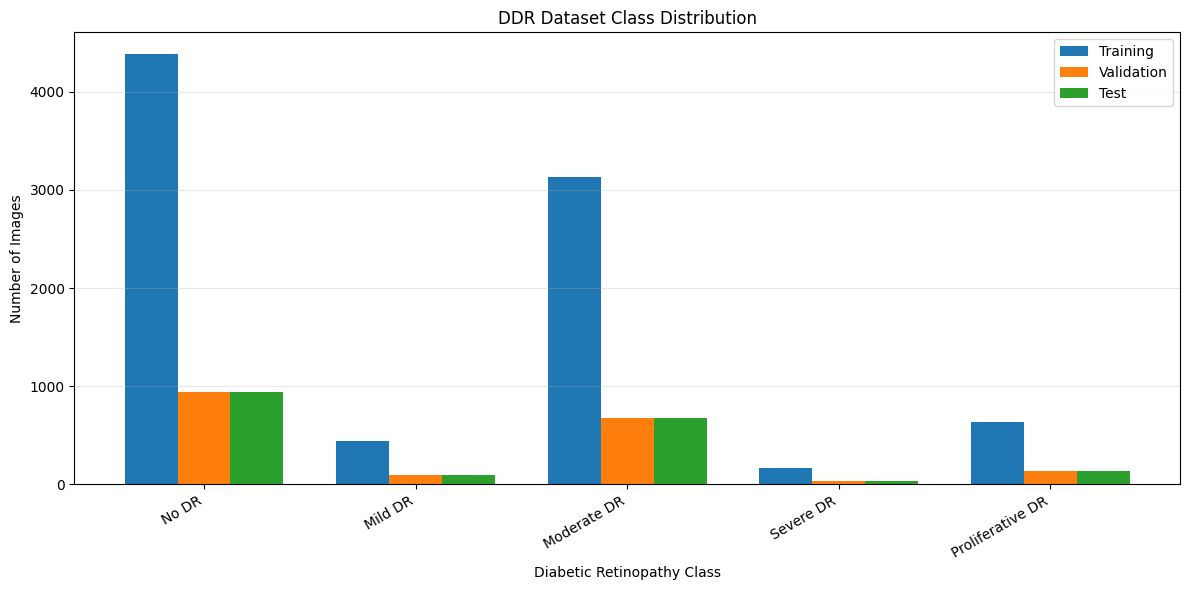

In [27]:
# STEP 27 - Class Distribution Visualization

class_names = [
    "No DR",
    "Mild DR",
    "Moderate DR",
    "Severe DR",
    "Proliferative DR"
]

train_counts = train_df["diagnosis"].value_counts().sort_index()
val_counts = val_df["diagnosis"].value_counts().sort_index()
test_counts = test_df["diagnosis"].value_counts().sort_index()

x = np.arange(NUM_CLASSES)
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, train_counts.values, width, label="Training")
plt.bar(x, val_counts.values, width, label="Validation")
plt.bar(x + width, test_counts.values, width, label="Test")

plt.xticks(x, class_names, rotation=30, ha="right")
plt.xlabel("Diabetic Retinopathy Class")
plt.ylabel("Number of Images")
plt.title("DDR Dataset Class Distribution")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# STEP 28 - Class Weights Used During Training

class_weight_table = pd.DataFrame({
    "Class": class_names,
    "Class ID": classes,
    "Training Samples": train_counts.values,
    "Class Weight": [class_weights[int(c)] for c in classes]
})

class_weight_table["Class Weight"] = class_weight_table["Class Weight"].round(4)

print("Class Weights Used for EfficientNetB0 Training")
display(class_weight_table)

Class Weights Used for EfficientNetB0 Training


,Class,Class ID,Training Samples,Class Weight
0,No DR,0,4386,0.3997
1,Mild DR,1,441,3.9751
2,Moderate DR,2,3134,0.5593
3,Severe DR,3,165,10.6242
4,Proliferative DR,4,639,2.7433


In [29]:
# STEP 29 - EfficientNetB0 Model Complexity Summary

total_params = model.count_params()
trainable_params = sum(
    np.prod(variable.shape)
    for variable in model.trainable_variables
)
non_trainable_params = total_params - trainable_params

print("EfficientNetB0 - Model Complexity")
print("---------------------------------")
print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Non-trainable params  : {non_trainable_params:,}")

EfficientNetB0 - Model Complexity
---------------------------------
Total parameters      : 4,214,184
Trainable parameters  : 164,613
Non-trainable params  : 4,049,571


Results folder:
/content/drive/MyDrive/DL Assignment/EfficientNetB0_Results


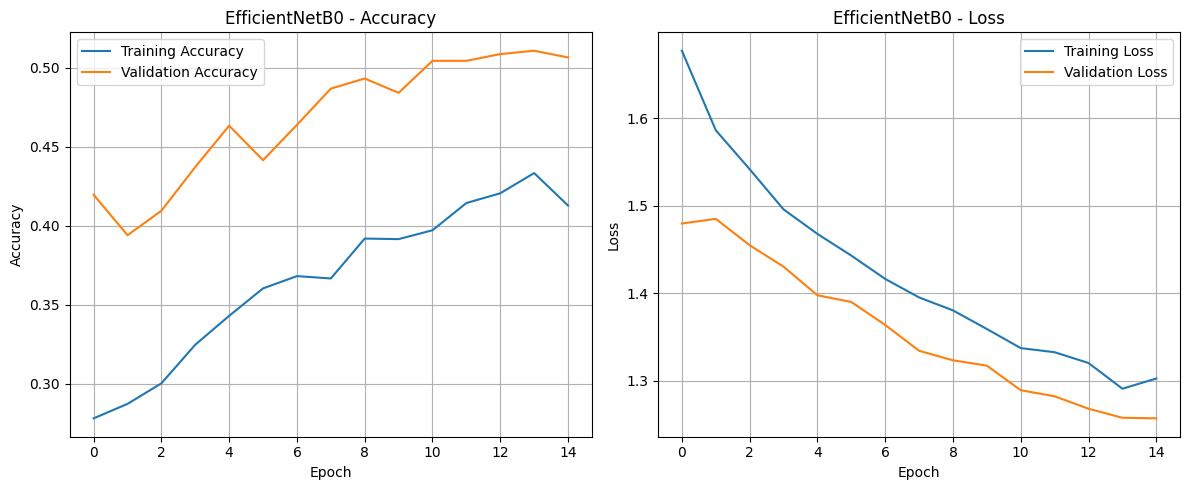

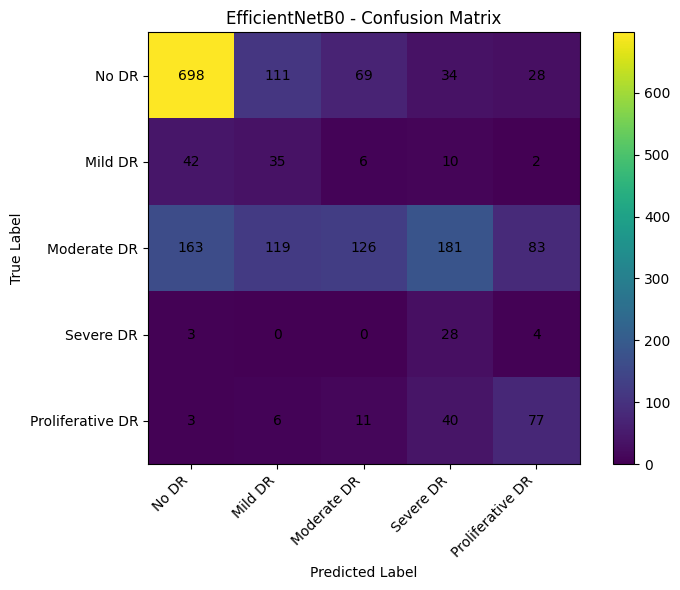

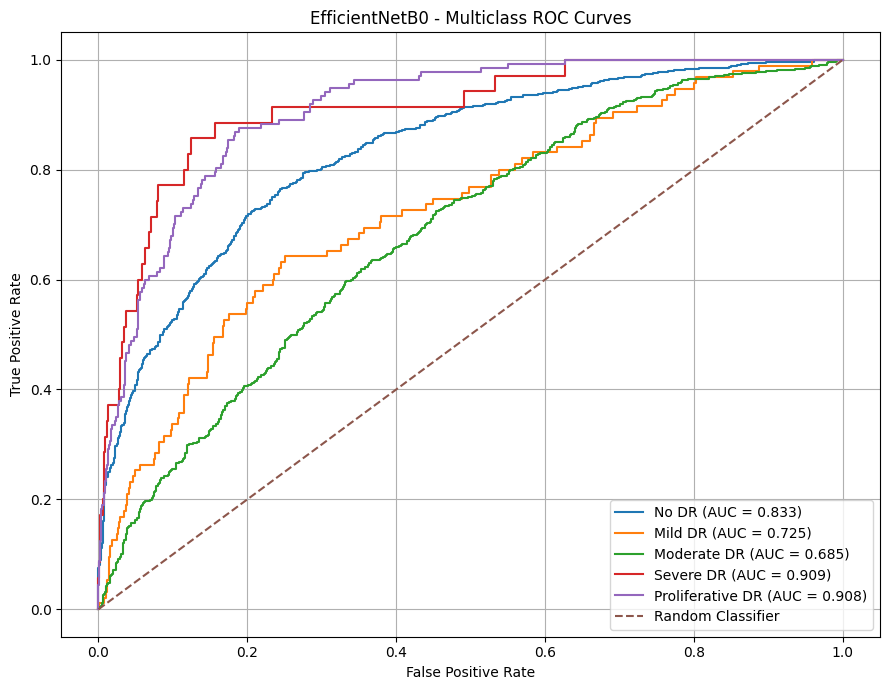


All results saved successfully.

Files in EfficientNetB0_Results:
- README.txt (0.5 KB)
- class_weights.csv (0.2 KB)
- classification_report.csv (0.6 KB)
- confusion_matrix.csv (0.2 KB)
- confusion_matrix.png (108.6 KB)
- final_test_metrics.csv (0.1 KB)
- model_complexity.txt (0.2 KB)
- roc_curves.png (166.8 KB)
- test_predictions.csv (239.1 KB)
- training_history.csv (1.5 KB)
- training_history.png (133.6 KB)


In [30]:
# STEP 31 - Save EfficientNetB0 Results to Google Drive

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ============================================================
# 1. Create permanent results folder in Google Drive
# ============================================================

results_dir = "/content/drive/MyDrive/DL Assignment/EfficientNetB0_Results"
os.makedirs(results_dir, exist_ok=True)

print("Results folder:")
print(results_dir)

# ============================================================
# 2. Save final metrics
# ============================================================

results_summary.to_csv(
    os.path.join(results_dir, "final_test_metrics.csv"),
    index=False
)

# ============================================================
# 3. Save training history
# ============================================================

history_df = pd.DataFrame(history.history)
history_df.index = history_df.index + 1
history_df.index.name = "Epoch"

history_df.to_csv(
    os.path.join(results_dir, "training_history.csv")
)

# ============================================================
# 4. Save classification report
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(
    os.path.join(results_dir, "classification_report.csv")
)

# ============================================================
# 5. Save confusion matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    os.path.join(results_dir, "confusion_matrix.csv")
)

# ============================================================
# 6. Save class weights
# ============================================================

class_weight_table.to_csv(
    os.path.join(results_dir, "class_weights.csv"),
    index=False
)

# ============================================================
# 7. Save training history graph
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(results_dir, "training_history.png"),
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 8. Save confusion matrix graph
# ============================================================

plt.figure(figsize=(8, 6))
plt.imshow(cm)

plt.title("EfficientNetB0 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig(
    os.path.join(results_dir, "confusion_matrix.png"),
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 9. Save ROC curves
# ============================================================

y_true_binary = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(9, 7))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true_binary[:, i],
        y_prob[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EfficientNetB0 - Multiclass ROC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(results_dir, "roc_curves.png"),
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ============================================================
# 10. Save model complexity information
# ============================================================

total_params = model.count_params()

trainable_params = sum(
    np.prod(variable.shape)
    for variable in model.trainable_variables
)

non_trainable_params = total_params - trainable_params

with open(
    os.path.join(results_dir, "model_complexity.txt"),
    "w"
) as f:

    f.write("EfficientNetB0 Model Complexity\n")
    f.write("================================\n")
    f.write(f"Total parameters: {total_params:,}\n")
    f.write(f"Trainable parameters: {trainable_params:,}\n")
    f.write(f"Non-trainable parameters: {non_trainable_params:,}\n")

# ============================================================
# 11. Save test predictions
# ============================================================

prediction_df = test_df[[
    "id_code",
    "diagnosis",
    "filepath"
]].copy()

prediction_df["true_class"] = y_true
prediction_df["predicted_class"] = y_pred

for i, class_name in enumerate(class_names):
    prediction_df[f"prob_{class_name.replace(' ', '_')}"] = y_prob[:, i]

prediction_df.to_csv(
    os.path.join(results_dir, "test_predictions.csv"),
    index=False
)

# ============================================================
# 12. Create a simple README for the results folder
# ============================================================

readme_text = """EfficientNetB0 Results
======================

Model:
EfficientNetB0 with ImageNet pretrained weights

Dataset:
DDR diabetic retinopathy dataset

Test samples:
1879

Final Test Metrics:
Accuracy: 51.30%
Weighted Precision: 63.39%
Weighted Recall: 51.30%
Weighted F1-Score: 52.64%
Macro ROC-AUC: 81.21%
Weighted ROC-AUC: 78.16%

Files:
- final_test_metrics.csv
- training_history.csv
- classification_report.csv
- confusion_matrix.csv
- class_weights.csv
- training_history.png
- confusion_matrix.png
- roc_curves.png
- model_complexity.txt
- test_predictions.csv
"""

with open(
    os.path.join(results_dir, "README.txt"),
    "w"
) as f:
    f.write(readme_text)

# ============================================================
# 13. Show saved files
# ============================================================

print("\nAll results saved successfully.")
print("\nFiles in EfficientNetB0_Results:")

for filename in sorted(os.listdir(results_dir)):
    file_path = os.path.join(results_dir, filename)
    size_kb = os.path.getsize(file_path) / 1024
    print(f"- {filename} ({size_kb:.1f} KB)")

## EfficientNetB0 Experimental Summary

EfficientNetB0 was trained using ImageNet pretrained weights with the backbone initially frozen and a custom five-class classification head. Class weights were applied during training to address the substantial class imbalance in the DDR dataset.

The model was trained for 15 epochs using the Adam optimizer with a learning rate of 1 × 10⁻⁵. The best model was selected based on validation loss and saved for final evaluation.

### Final Test Set Performance

- **Test Accuracy:** 51.30%
- **Weighted Precision:** 63.39%
- **Weighted Recall:** 51.30%
- **Weighted F1-Score:** 52.64%
- **Macro ROC-AUC:** 81.21%
- **Weighted ROC-AUC:** 78.16%

The confusion matrix shows that prediction performance varies across diabetic retinopathy severity classes. The ROC analysis also shows different discriminative performance across the five classes.

The final test evaluation was performed on the held-out test set containing 1,879 images, which was not used during model training or model selection.